# AutoCallable Analytics — Vol Models & Pricing Methods
## Conceptual Q&A Reference Guide

This notebook captures key conceptual questions and explanations on the theoretical foundations of the AutoCallable Analytics Platform, based on the three reference papers:

| Paper | Authors | Key Concepts |
|-------|---------|-------------|
| `modeling-autocallable-structured-products.pdf` | Deng, Mallett, McCann (2011) | PDE framework, FDM, call probabilities |
| `LocalStochasticJumps.pdf` | Haugh, Columbia IEOR (2013) | Local vol, Heston, Bates, characteristic functions |
| `StableDiffs.pdf` | Alm, Harrach, Harrach, Keller (2013) | One-step survival MC, stable Greeks |

### Topics
1. [Implied Vol Surface vs. Dupire Local Vol Surface](#1)
2. [How Local Vol Is Derived from Market Prices — The Dupire Formula](#2)
3. [Why the Local Vol Surface Appears Jagged](#3)
4. [Finite Difference Method — The Explicit Scheme](#4)
5. [Crank-Nicolson — Stable Alternative to Explicit FDM](#5)
6. [Heston Model — When Volatility Is Random](#6)
7. [Bates Model — Heston + Jump Risk](#7)
8. [Design Decisions: ADI vs Char. Functions; Gil-Pelaez vs Carr-Madan](#8)

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from scipy import integrate
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

def bs_call(S, K, T, r, sigma, q=0.0):
    if sigma <= 0 or T <= 0:
        return max(S*np.exp(-q*T) - K*np.exp(-r*T), 0)
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def implied_vol(C_mkt, S, K, T, r, q=0.0):
    try:
        return brentq(lambda s: bs_call(S,K,T,r,s,q) - C_mkt, 1e-6, 5.0)
    except ValueError:
        return np.nan

print("Setup complete.")

Setup complete.


---
<a id="1"></a>
## 1. Implied Vol Surface vs. Dupire Local Vol Surface

### The Core Distinction

**Implied volatility** is a *per-option* quantity. For each traded option (K, T), ask: what constant σ makes the Black-Scholes formula match the market price? The surface is thousands of these individual inversions on a (K, T) grid — a quoting convention, not a model.

**Local volatility** (Dupire, 1994) is a *function* σ(S, t) — one value for every (stock price, time) point in the future. One surface simultaneously reproduces the prices of *all* market options.

### Key Differences

| | Implied Vol Surface | Dupire Local Vol Surface |
|---|---|---|
| What it is | Per-option BS inversion | Function σ(S, t) of price and time |
| Inputs | One market price → one vol | Entire market surface → entire σ(S,t) grid |
| Prices options | One option per vol | All options simultaneously |
| Shape | Smile / skew (shallower) | Steeper skew (~2× implied across strikes) |
| How computed | Back out σ from BS formula | Differentiate the call price surface |

### Why Local Vol Skew Is Steeper

Implied vol skew measures how vol *appears* to vary with strike (through the BS lens). Local vol skew measures how vol *actually must vary locally* to reproduce those prices. These two slopes are related by roughly a factor of 2 — local vol moves ~twice as fast across strikes as implied vol.

**Why it matters for autocallables:** the knock-in put at 75% of spot is triggered in the high-local-vol region below the barrier. Local vol captures this level-dependence; flat BS vol completely ignores it.

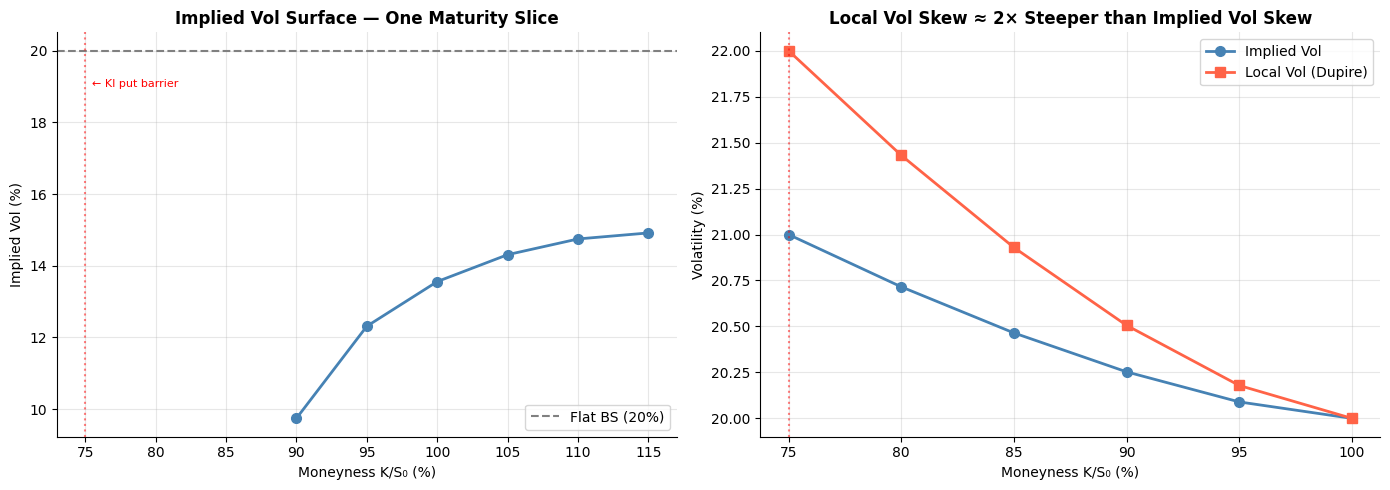

Key takeaway: local vol 'sees' the same market data but through a different lens.
It extracts the point-in-time, location-specific vol — not a per-option average.


In [3]:
# Implied vol surface for one maturity — demonstrating the skew
S, r, q, T = 100, 0.05, 0.015, 1.0
strikes    = [75, 80, 85, 90, 95, 100, 105, 110, 115]
mkt_prices = [26.2, 22.1, 17.4, 13.2, 9.8, 7.1, 5.0, 3.4, 2.2]  # SPX-like skew

ivols = [implied_vol(C, S, K, T, r, q) for C, K in zip(mkt_prices, strikes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot([K/S*100 for K in strikes], [iv*100 for iv in ivols], 'o-',
         color='steelblue', lw=2, ms=7)
ax1.axhline(np.sqrt(0.04)*100, color='gray', ls='--', lw=1.5, label='Flat BS (20%)')
ax1.set_xlabel('Moneyness K/S₀ (%)'); ax1.set_ylabel('Implied Vol (%)')
ax1.set_title('Implied Vol Surface — One Maturity Slice', fontweight='bold'); ax1.legend()
ax1.axvline(75, color='red', ls=':', alpha=0.5); ax1.text(75.5, 19, '← KI put barrier', fontsize=8, color='red')

# Schematic comparison: implied vol skew vs local vol skew (2x steeper)
moneyness = np.array([75,80,85,90,95,100,105,110,115]) / 100
iv_skew   = 0.20 + 0.08*(1 - moneyness)**1.5   # approximate IV skew
lv_skew   = 0.20 + 0.16*(1 - moneyness)**1.5   # LV skew ~ 2x steeper
ax2.plot(moneyness*100, iv_skew*100, 'o-', color='steelblue', lw=2, ms=7, label='Implied Vol')
ax2.plot(moneyness*100, lv_skew*100, 's-', color='tomato',    lw=2, ms=7, label='Local Vol (Dupire)')
ax2.set_xlabel('Moneyness K/S₀ (%)'); ax2.set_ylabel('Volatility (%)')
ax2.set_title('Local Vol Skew ≈ 2× Steeper than Implied Vol Skew', fontweight='bold'); ax2.legend()
ax2.axvline(75, color='red', ls=':', alpha=0.5)

plt.tight_layout(); plt.show()
print("Key takeaway: local vol 'sees' the same market data but through a different lens.")
print("It extracts the point-in-time, location-specific vol — not a per-option average.")

---
<a id="2"></a>
## 2. How Local Vol Is Derived from Market Prices — The Dupire Formula

### No Monte Carlo Involved

Local vol is derived **purely analytically** from the call price surface — it is a mathematical operation on market data, not a simulation.

### The Five-Step Workflow

```
Step 1 — Market option prices C(K, T) across many (strike, maturity) pairs
              ↓
Step 2 — Back out implied vols σ_IV(K, T)   [one BS inversion per option]
              ↓
Step 3 — Fit a SMOOTH parametric surface (SVI or cubic spline)
              ↓  ← critical: smooth BEFORE differentiating
Step 4 — Compute derivatives of the smooth call price surface:
              ∂C/∂T  — how fast price grows with maturity (time edge)
              ∂²C/∂K² — how curved prices are across strikes (strike curvature)
              ↓
Step 5 — Apply Dupire's formula:
              σ²_local(T, K) = [∂C/∂T + (r−q)K·∂C/∂K + q·C] / [½K²·∂²C/∂K²]
```

### Intuition

Dupire showed the call price surface encodes local vol through two features:

- **∂C/∂T (time edge):** how quickly the option gains value as maturity extends. Measures the variance the stock accumulates near that strike.
- **∂²C/∂K² (strike curvature):** how curved call prices are across strikes. Proportional to the probability density of the stock being near K at time T.

**σ_local = √(time edge / strike curvature)**

MC is used *later* when pricing derivatives using the local vol surface — but deriving the surface itself is purely analytical.

In [4]:
# ── Dupire Formula: Worked Numerical Example ──────────────────────────────────

K_grid = np.array([95.0, 100.0, 105.0])
T_grid = np.array([0.5,   1.0,   1.5 ])
dK, dT = K_grid[1]-K_grid[0], T_grid[1]-T_grid[0]
r, q   = 0.05, 0.015

#                 K=95    K=100   K=105
C = np.array([[10.50,   7.20,   4.80],   # T = 0.5
              [13.80,  10.20,   7.40],   # T = 1.0
              [16.50,  12.80,   9.70]])  # T = 1.5

K0, T0, i, j = 100.0, 1.0, 1, 1

dC_dT    = (C[i+1,j] - C[i-1,j]) / (2*dT)
dC_dK    = (C[i,j+1] - C[i,j-1]) / (2*dK)
d2C_dK2  = (C[i,j-1] - 2*C[i,j] + C[i,j+1]) / dK**2

numerator   = dC_dT + (r-q)*K0*dC_dK + q*C[i,j]
denominator = 0.5 * K0**2 * d2C_dK2
local_var   = numerator / denominator
local_vol   = np.sqrt(abs(local_var))

print("Call Price Surface:")
header = "         " + "  ".join(f"K={int(k):3}" for k in K_grid)
print(header)
for ti, row in zip(T_grid, C):
    print(f"  T={ti:.1f}:  " + "  ".join(f"{v:5.2f}" for v in row))

print(f'Dupire Calculation at K={K0:.0f}, T={T0:.1f}:')
print(f'  dC/dT  (time edge)             = ({C[2,1]:.2f} - {C[0,1]:.2f}) / (2x{dT})  = {dC_dT:.4f}')
print(f'  dC/dK  (delta)                 = ({C[1,2]:.2f} - {C[1,0]:.2f}) / (2x{dK})  = {dC_dK:.4f}')
print(f'  d2C/dK2 (strike curvature)     = ({C[1,0]:.2f} - 2x{C[1,1]:.2f} + {C[1,2]:.2f}) / {dK}^2 = {d2C_dK2:.6f}')
print(f'  Numerator  (dC/dT + rate adj.) = {numerator:.4f}')
print(f'  Denominator (0.5K^2 x curv.)   = 0.5 x {K0:.0f}^2 x {d2C_dK2:.6f}  = {denominator:.4f}')
print(f'  Local variance sigma^2_local   = {local_var:.4f}')
print(f'  Local vol      sigma_local     = {local_vol*100:.1f}%')

Call Price Surface:
         K= 95  K=100  K=105
  T=0.5:  10.50   7.20   4.80
  T=1.0:  13.80  10.20   7.40
  T=1.5:  16.50  12.80   9.70
Dupire Calculation at K=100, T=1.0:
  dC/dT  (time edge)             = (12.80 - 7.20) / (2x0.5)  = 5.6000
  dC/dK  (delta)                 = (7.40 - 13.80) / (2x5.0)  = -0.6400
  d2C/dK2 (strike curvature)     = (13.80 - 2x10.20 + 7.40) / 5.0^2 = 0.032000
  Numerator  (dC/dT + rate adj.) = 3.5130
  Denominator (0.5K^2 x curv.)   = 0.5 x 100^2 x 0.032000  = 160.0000
  Local variance sigma^2_local   = 0.0220
  Local vol      sigma_local     = 14.8%


---
<a id="3"></a>
## 3. Why the Local Vol Surface Appears Jagged

### Root Cause: Differentiation Amplifies Noise

**The road analogy:** a road can look smooth when you plot its height vs. distance. The slope (first derivative) shows moderate variation. But the curvature (second derivative) can oscillate dramatically — even when the road looks perfectly smooth. Dupire's formula divides two noisy derivatives. Any small imperfection in the surface gets amplified dramatically.

### Three Specific Causes

**1. Discrete expiry dates → ∂C/∂T is a finite difference across jumps**

Real options expire on specific dates. The time derivative is computed as (C at next expiry − C at this expiry) / date gap. If the Dec→Jan gap is 4 weeks but Jan→Mar is 8 weeks, the "time slope" jumps discontinuously at each expiry boundary. Spikes in local vol cluster exactly at these boundaries.

**2. Near-zero denominator at short maturities**

For short maturities, call prices have nearly zero curvature (∂²C/∂K² → 0) away from ATM. Division by near-zero → local vol spikes. The cluster of spikes at short T near ATM comes from this.

**3. Cubic splines: smooth visually, noisy in second derivatives**

A cubic spline guarantees C² continuity within intervals, but the third derivative can jump at knots. Dupire needs the second K-derivative, which can oscillate between data points even when the spline looks smooth.

### The Fix: SVI Fitting Before Differentiating

Fit SVI (Stochastic Volatility Inspired) in total variance space W = σ²·T as a function of log-moneyness. SVI is explicitly designed to be smooth enough to differentiate analytically. Industry standard precisely because Dupire from raw splines produces the jagged surface.

### Demo Value

The jagged local vol in the app is actually a useful teaching point: it shows exactly *why* parametric models (Heston, Bates) are preferred over Dupire for exotic product pricing in practice — analytical stability vs. amplified-noise differentiation.

ValueError: x and y must have same first dimension, but have shapes (299,) and (300,)

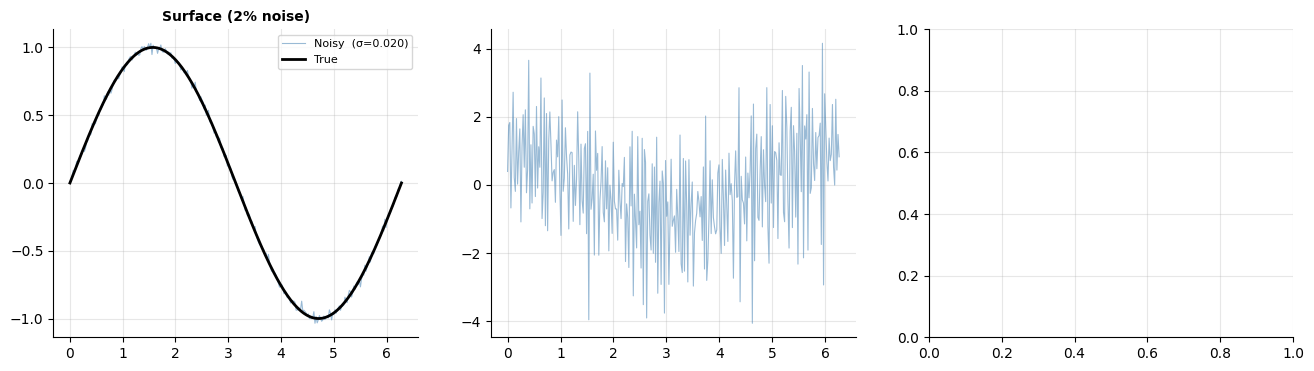

In [5]:
# ── How differentiation amplifies noise ───────────────────────────────────────
np.random.seed(42)
x  = np.linspace(0, 2*np.pi, 300)
dx = x[1] - x[0]

true_fn  = np.sin(x)
noisy_fn = true_fn + 0.02 * np.random.randn(len(x))

true_d1  =  np.cos(x)
noisy_d1 = np.diff(noisy_fn) / dx

true_d2  = -np.sin(x)
noisy_d2 = np.diff(noisy_d1) / dx

noise = [np.std(noisy_fn - true_fn),
         np.std(noisy_d1 - true_d1[:-1]),
         np.std(noisy_d2 - true_d2[:-2])]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, x_, true_, noisy_, title_, amp in zip(
        axes,
        [x, x[:-1], x[:-2]],
        [true_fn, true_d1, true_d2],
        [noisy_fn, noisy_d1, noisy_d2],
        ['Surface (2% noise)', '1st Derivative (dC/dT in Dupire)', '2nd Derivative (d2C/dK2) - Dupire needs this!'],
        noise):
    ax.plot(x_, noisy_, 'steelblue', alpha=0.55, lw=0.8, label=f'Noisy  (σ={amp:.3f})')
    ax.plot(x_, true_,  'black',    lw=2,        label='True')
    ax.set_title(title_, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Differentiation Amplifies Noise — Same 2% Input Noise Throughout', fontsize=12)
plt.tight_layout(); plt.show()

print(f"Input noise σ:              {noise[0]:.4f}")
print(f"1st derivative noise σ:     {noise[1]:.4f}   ({noise[1]/noise[0]:.0f}× amplification)")
print(f"2nd derivative noise σ:     {noise[2]:.4f}  ({noise[2]/noise[0]:.0f}× amplification)")
print()
print("Dupire = numerator(noisy 1st deriv) / denominator(noisy 2nd deriv)")
print("→ spikes wherever denominator is small OR noise is large relative to signal")

---
<a id="4"></a>
## 4. Finite Difference Method — The Explicit Scheme

### The PDE Being Solved

The Black-Scholes PDE for an option V(S, t):

$$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + (r-q)S\frac{\partial V}{\partial S} - (r + \text{cds})V = 0$$

Solving directly on (S, t) is messy because of S² and S coefficient terms. Paper 1 (Deng et al.) applies a change of variables that transforms this into the **heat equation**.

### Change of Variables → Heat Equation

Let x = log(S/C) where C is the call barrier. After substitution:

$$\frac{\partial u}{\partial \tau} = \frac{\partial^2 u}{\partial x^2}$$

Same as heat diffusing through a metal rod — the simplest PDE to solve numerically.

**Grid:** x ∈ [−5, 0] (N=1000 steps, δx=0.005),  τ ∈ [0, τ_max] (M=500 steps)

- x = 0: stock at the autocall barrier
- x = −5: stock near zero

### The Explicit Update Rule

$$\boxed{u[m+1][n] = u[m][n] + \lambda \cdot (u[m][n+1] - 2u[m][n] + u[m][n-1])}$$

where **λ = δτ / δx²**

"Explicit" = the new value is expressed directly in terms of current values. No system of equations — one formula per grid point.

**Intuitively:** the new value = old value + a "diffusion correction" pulling it toward the average of its neighbors. Exactly like heat spreading from hot to cold.

### Stability Condition (CFL)

**λ must be ≤ ½.** If violated, the coefficient (1−2λ) goes negative — you subtract more than 100% of the current value, errors grow exponentially. With δx=0.005: δτ ≤ 0.0000125, forcing M ≥ 500. **Stability determines grid density, not accuracy.**

### Backward Sweep

```
1. τ=0 (maturity T): initialize u from terminal payoff
2. For each τ step: apply explicit update + boundary conditions
3. At each observation date: lock n where S ≥ barrier (autocall coupon payoff)
4. At τ=τ_max (today): read off u[M][n*] at S = S₀
```

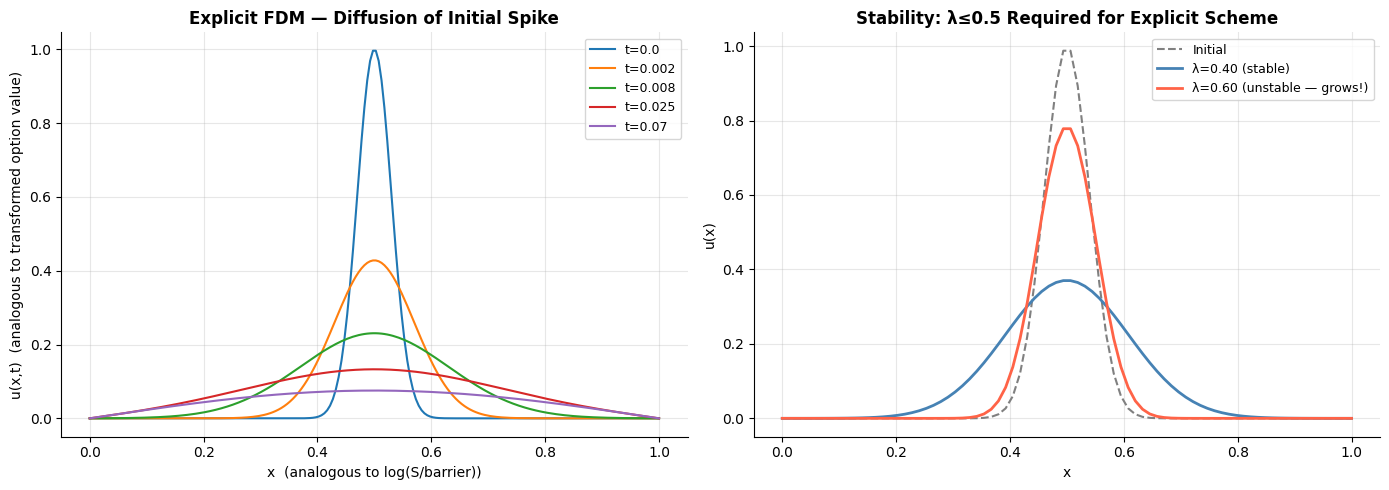

With δx=0.005 (N=1000): max stable δτ = 0.5×0.005² = 1.25e-05
Over T=2yrs: requires M ≥ 160,001 time steps just for stability!


In [6]:
def explicit_fdm(u_init, dx, dt, T_end, bc_l=0.0, bc_r=0.0):
    '''Explicit FDM for heat equation du/dt = d2u/dx2. Checks stability.'''
    lam = dt / dx**2
    if lam > 0.5 + 1e-10:
        raise ValueError(f"Stability violated: λ={lam:.4f} > 0.5. Reduce dt or increase dx.")
    u, t = u_init.copy(), 0
    while t < T_end - 1e-12:
        dt_s  = min(dt, T_end - t)
        lam_s = dt_s / dx**2
        u_new = u.copy()
        u_new[1:-1] = u[1:-1] + lam_s*(u[2:] - 2*u[1:-1] + u[:-2])
        u_new[0], u_new[-1] = bc_l, bc_r
        u, t = u_new, t + dt_s
    return u

N  = 200;  x  = np.linspace(0, 1, N);  dx = x[1]-x[0]
dt = 0.4 * dx**2   # λ = 0.4  — well within stability limit
u0 = np.exp(-((x - 0.5)**2) / (2*0.03**2)); u0[0] = u0[-1] = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: diffusion snapshots
for T_s in [0.0, 0.002, 0.008, 0.025, 0.07]:
    u_s = explicit_fdm(u0, dx, dt, T_s)
    ax1.plot(x, u_s, label=f't={T_s}')
ax1.set_title('Explicit FDM — Diffusion of Initial Spike', fontweight='bold')
ax1.set_xlabel('x  (analogous to log(S/barrier))')
ax1.set_ylabel('u(x,t)  (analogous to transformed option value)')
ax1.legend(fontsize=9)

# Right: stability demo — stable vs unstable λ
x2 = np.linspace(0,1,80); dx2 = x2[1]-x2[0]
u02 = np.exp(-((x2-0.5)**2)/(2*0.04**2)); u02[0]=u02[-1]=0
u_stable = explicit_fdm(u02, dx2, 0.4*dx2**2, 0.005)

# Simulate one unstable step manually (λ=0.6)
lam_bad = 0.6
u_unstable = u02.copy()
for _ in range(5):
    u_tmp = u_unstable.copy()
    u_tmp[1:-1] = u_unstable[1:-1] + lam_bad*(u_unstable[2:] - 2*u_unstable[1:-1] + u_unstable[:-2])
    u_unstable = u_tmp

ax2.plot(x2, u02,       'gray',      lw=1.5, ls='--', label='Initial')
ax2.plot(x2, u_stable,  'steelblue', lw=2,   label=f'λ=0.40 (stable)')
ax2.plot(x2, np.clip(u_unstable,-3,3), 'tomato', lw=2, label=f'λ=0.60 (unstable — grows!)')
ax2.set_title('Stability: λ≤0.5 Required for Explicit Scheme', fontweight='bold')
ax2.set_xlabel('x'); ax2.set_ylabel('u(x)'); ax2.legend(fontsize=9)

plt.tight_layout(); plt.show()
print(f"With δx=0.005 (N=1000): max stable δτ = 0.5×0.005² = {0.5*0.005**2:.2e}")
print(f"Over T=2yrs: requires M ≥ {int(2/(0.5*0.005**2))+1:,} time steps just for stability!")

---
<a id="5"></a>
## 5. Crank-Nicolson — Stable Alternative to Explicit FDM

### Motivation

The explicit scheme is forced to use tiny time steps (λ ≤ ½) for stability — not accuracy. The solution is a scheme that is **unconditionally stable** for any λ.

### Two Ingredients

**Explicit:** space derivative at the *current* step m (known values only)

**Fully Implicit:** space derivative at the *next* step m+1 (all unknowns) — unconditionally stable, but only 1st-order accurate

**Crank-Nicolson = average the two** — space derivative evaluated at the midpoint m+½.  
The 1st-order errors from both halves cancel → **2nd-order accuracy**. Unconditionally stable.

### The Tridiagonal System

After rearranging (unknowns on left, known RHS on right):

$$-\frac{\lambda}{2}\, u^{m+1}_{n-1} \;+\; (1+\lambda)\, u^{m+1}_n \;-\; \frac{\lambda}{2}\, u^{m+1}_{n+1} = \frac{\lambda}{2}\, u^m_{n-1} + (1-\lambda)\, u^m_n + \frac{\lambda}{2}\, u^m_{n+1}$$

Written as **A · u^{m+1} = b^m** where A is tridiagonal:

```
Main diagonal:   (1+λ)
Off-diagonals:  −λ/2
```

### Thomas Algorithm — O(N) Tridiagonal Solver

Naive Gaussian elimination is O(N³). Thomas algorithm exploits the tridiagonal structure: forward sweep (top to bottom) + backward substitution (bottom to top) in ~5N operations. Same O(N) cost as the explicit update.

### Comparison

| | Explicit | Crank-Nicolson |
|---|---|---|
| Stability | λ ≤ ½ required | **Unconditionally stable** |
| Time accuracy | O(δτ) — 1st order | **O(δτ²) — 2nd order** |
| Steps needed | Large M (stability-forced) | Small M sufficient |
| Cost per step | O(N) — one formula | O(N) — Thomas algorithm |

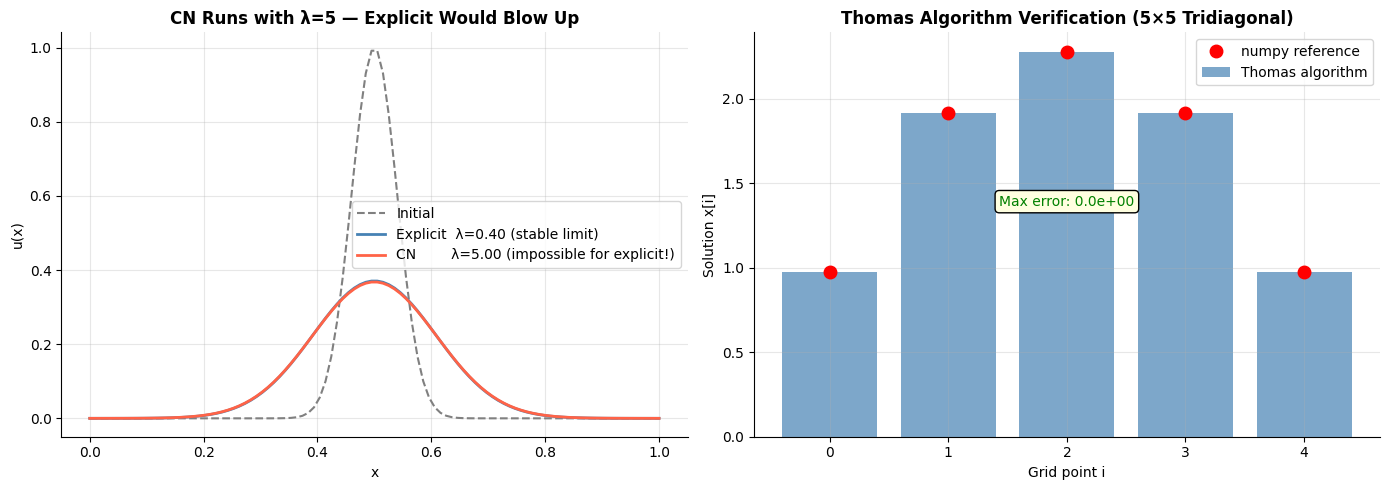

In [7]:
def thomas_solve(a, b, c, d):
    '''Thomas algorithm -- O(N) tridiagonal solver.
    a[i]*x[i-1] + b[i]*x[i] + c[i]*x[i+1] = d[i]
    a: sub-diag (a[0] ignored), b: main diag, c: super-diag (c[-1] ignored)
    '''
    N = len(b)
    b, c, d = b.astype(float).copy(), c.astype(float).copy(), d.astype(float).copy()
    for i in range(1, N):             # forward sweep
        m    = a[i] / b[i-1]
        b[i] -= m * c[i-1]
        d[i] -= m * d[i-1]
    x = np.zeros(N)
    x[-1] = d[-1] / b[-1]
    for i in range(N-2, -1, -1):     # backward substitution
        x[i] = (d[i] - c[i]*x[i+1]) / b[i]
    return x

def crank_nicolson_fdm(u_init, dx, dt, T_end, bc_l=0.0, bc_r=0.0):
    '''Crank-Nicolson for heat equation -- unconditionally stable.'''
    N = len(u_init)
    lam = dt / dx**2
    a = np.zeros(N);  a[1:] = -lam/2
    b = (1 + lam) * np.ones(N);  b[0] = b[-1] = 1
    c = np.zeros(N);  c[:-1] = -lam/2
    u, t = u_init.copy(), 0
    while t < T_end - 1e-12:
        rhs = np.zeros(N)
        rhs[1:-1] = lam/2*u[:-2] + (1-lam)*u[1:-1] + lam/2*u[2:]
        rhs[0], rhs[-1] = bc_l, bc_r
        u, t = thomas_solve(a, b, c, rhs), t + min(dt, T_end-t)
    return u

# ── CN with large λ vs Explicit — stability comparison ───────────────────────
N2 = 100; x2 = np.linspace(0,1,N2); dx2 = x2[1]-x2[0]
u02 = np.exp(-((x2-0.5)**2)/(2*0.04**2)); u02[0]=u02[-1]=0; T_e=0.005

u_exp = explicit_fdm(u02, dx2, 0.4*dx2**2, T_e)
u_cn5 = crank_nicolson_fdm(u02, dx2, 5.0*dx2**2, T_e)   # λ=5 — impossible for explicit

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(x2, u02,   'gray',      lw=1.5, ls='--', label='Initial')
ax1.plot(x2, u_exp, 'steelblue', lw=2,   label='Explicit  λ=0.40 (stable limit)')
ax1.plot(x2, u_cn5, 'tomato',    lw=2,   label='CN        λ=5.00 (impossible for explicit!)')
ax1.set_title('CN Runs with λ=5 — Explicit Would Blow Up', fontweight='bold')
ax1.set_xlabel('x'); ax1.set_ylabel('u(x)'); ax1.legend()

# Thomas algorithm verification on small system
lam_v = 2.0; N5 = 5
a5 = np.r_[0.0, -lam_v/2*np.ones(N5-1)]
b5 = (1+lam_v)*np.ones(N5)
c5 = np.r_[-lam_v/2*np.ones(N5-1), 0.0]
d5 = np.array([1.0,2.5,3.0,2.5,1.0])
x_t = thomas_solve(a5, b5, c5, d5)
A5  = np.diag(b5) + np.diag(a5[1:],-1) + np.diag(c5[:-1],1)
x_n = np.linalg.solve(A5, d5)

ax2.bar(range(N5), x_t, alpha=0.7, color='steelblue', label='Thomas algorithm')
ax2.plot(range(N5), x_n, 'ro', ms=9, zorder=3, label='numpy reference')
ax2.set_title('Thomas Algorithm Verification (5×5 Tridiagonal)', fontweight='bold')
ax2.set_xlabel('Grid point i'); ax2.set_ylabel('Solution x[i]'); ax2.legend()
ax2.text(2, max(x_t)*0.6, f'Max error: {np.max(np.abs(x_t-x_n)):.1e}', ha='center',
         fontsize=10, color='green', bbox=dict(facecolor='lightyellow',boxstyle='round'))

plt.tight_layout(); plt.show()

---
<a id="6"></a>
## 6. Heston Model — When Volatility Is Random

### What BS and Local Vol Can't Capture

Both Black-Scholes and Dupire local vol assume volatility is *deterministic* — given S and t, you know σ exactly. Real volatility clusters, mean-reverts, and is itself uncertain. Heston (1993) treats variance v = σ² as its own random process.

### The Two SDEs

$$dS_t = (r - q)\, S_t\, dt + \sqrt{v_t}\cdot S_t\, dW_S$$

$$dv_t = \kappa(\theta - v_t)\, dt + \gamma\sqrt{v_t}\, dW_v, \quad \text{Corr}(dW_S, dW_v) = \rho$$

| Parameter | Meaning | Typical SPX |
|---|---|---|
| v₀ | Today's variance (σ² now) | ~0.04 = 20% vol |
| κ | Mean-reversion speed | 1–5 |
| θ | Long-run variance | ~0.04 |
| γ | Vol-of-vol | 0.3–1.0 |
| ρ | Stock/vol correlation | −0.7 to −0.9 |

**ρ generates the skew.** Negative ρ: when stock falls, vol rises — making downside options more expensive. This matches market reality (the leverage effect).

### The 3D PDE and Why We Skip It

Heston's two state variables (S, v) create a 3D PDE in (S, v, t). The mixed derivative ρ·γ·v·S·∂²V/∂S∂v couples the two spatial dimensions, requiring specialized ADI schemes. See Section 8 for why we skip this.

### Characteristic Function + Gil-Pelaez Inversion

Heston showed the **Fourier transform of log(S_T)** — the characteristic function φ(u) — has an exact closed-form expression (Eq. 23, branch-cut safe form). European call prices follow via Gil-Pelaez inversion:

$$C = S_0 e^{-qT} P_1 - K e^{-rT} P_2 \quad \text{where} \quad P_j = \frac{1}{2} + \frac{1}{\pi}\int_0^\infty \text{Re}\!\left[\frac{e^{-iu\log K}\,\phi_j(u)}{iu}\right]du$$

Each integral evaluates in ~1ms. No 3D PDE needed for calibration.

### Calibration

Minimize sum of squared vol errors across observed (K_j, T_j) pairs:  
min over {κ, θ, γ, ρ, v₀} of Σⱼ [σ_model(K_j, T_j) − σ_market(K_j, T_j)]²  
Subject to: κ,θ,γ,v₀ > 0; −1 < ρ < 0; κθ > ½γ² (Feller condition)

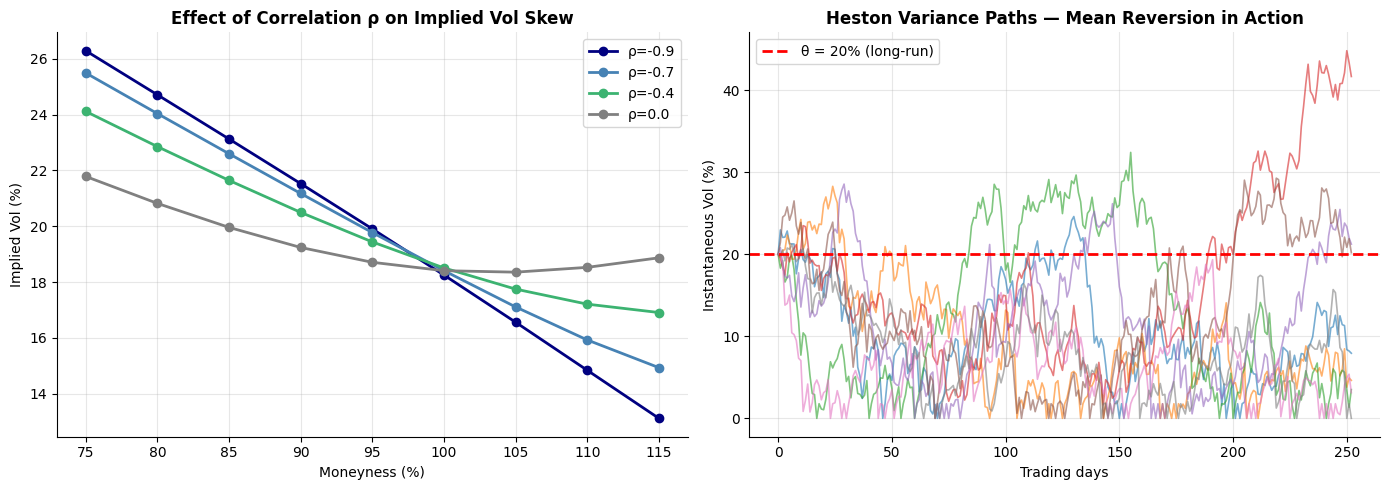

Feller condition: κθ > ½γ²  →  2.0×0.04 = 0.0800 > 0.1800 = ½×0.6²
✗ Feller violated!


In [8]:
def heston_cf(u, S0, v0, kappa, theta, gamma, rho, r, q, T):
    '''Heston CF -- Eq. 23 (branch-cut safe). Never use the alternative phi-hat form.'''
    iu = 1j*u
    d  = np.sqrt((rho*gamma*iu - kappa)**2 + gamma**2*(iu + u**2))
    g  = (kappa - rho*gamma*iu - d) / (kappa - rho*gamma*iu + d)
    A  = iu*(np.log(S0) + (r-q)*T)
    B  = (theta*kappa/gamma**2)*((kappa - rho*gamma*iu - d)*T
         - 2*np.log((1 - g*np.exp(-d*T))/(1-g)))
    C_cf = (v0/gamma**2)*(kappa - rho*gamma*iu - d)*(1-np.exp(-d*T))/(1-g*np.exp(-d*T))
    return np.exp(A+B+C_cf)

def heston_call(S0, K, T, r, q, v0, kappa, theta, gamma, rho, u_max=100, n_pts=200):
    '''European call via Gil-Pelaez inversion.'''
    log_K = np.log(K)
    def ig(u, j):
        sh = -1j if j==1 else 0j
        ph = heston_cf(u+sh, S0, v0, kappa, theta, gamma, rho, r, q, T)
        ph0= heston_cf(sh,   S0, v0, kappa, theta, gamma, rho, r, q, T)
        return np.real(np.exp(-1j*u*log_K)*ph/(1j*u*ph0))
    P1 = 0.5 + integrate.quad(ig,1e-6,u_max,args=(1,),limit=n_pts)[0]/np.pi
    P2 = 0.5 + integrate.quad(ig,1e-6,u_max,args=(2,),limit=n_pts)[0]/np.pi
    return S0*np.exp(-q*T)*P1 - K*np.exp(-r*T)*P2

S0, r, q, T = 100, 0.05, 0.015, 1.0
v0, kappa, theta, gamma = 0.04, 2.0, 0.04, 0.6
strikes = np.array([75,80,85,90,95,100,105,110,115])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Left: effect of rho on skew
for rho_v, col in [(-0.9,'navy'),(-0.7,'steelblue'),(-0.4,'mediumseagreen'),(0.0,'gray')]:
    ivs = [implied_vol(heston_call(S0,K,T,r,q,v0,kappa,theta,gamma,rho_v),S0,K,T,r,q) for K in strikes]
    ax1.plot(strikes/S0*100,[iv*100 for iv in ivs],'o-',color=col,lw=2,ms=6,label=f'ρ={rho_v}')
ax1.set_title('Effect of Correlation ρ on Implied Vol Skew', fontweight='bold')
ax1.set_xlabel('Moneyness (%)'); ax1.set_ylabel('Implied Vol (%)'); ax1.legend()

# Right: Feller condition — variance paths
rho = -0.75
np.random.seed(7)
dt_mc, N_mc = 1/252, 252
for _ in range(8):
    v, vpath = v0, [v0]
    for _ in range(N_mc):
        dW = np.random.randn()*np.sqrt(dt_mc)
        v  = max(v + kappa*(theta-v)*dt_mc + gamma*np.sqrt(v)*dW, 0)
        vpath.append(v)
    ax2.plot(np.sqrt(vpath)*100, alpha=0.6, lw=1.2)
ax2.axhline(np.sqrt(theta)*100, color='red', lw=2, ls='--', label=f'θ = {np.sqrt(theta)*100:.0f}% (long-run)')
ax2.set_title('Heston Variance Paths — Mean Reversion in Action', fontweight='bold')
ax2.set_xlabel('Trading days'); ax2.set_ylabel('Instantaneous Vol (%)'); ax2.legend()

plt.tight_layout(); plt.show()
print(f"Feller condition: κθ > ½γ²  →  {kappa}×{theta} = {kappa*theta:.4f} > {0.5*gamma**2:.4f} = ½×{gamma}²")
print(f"{'✓ Feller satisfied — variance stays positive' if kappa*theta > 0.5*gamma**2 else '✗ Feller violated!'}")

---
<a id="7"></a>
## 7. Bates Model — Heston + Jump Risk

### What Heston Still Can't Capture

Heston moves continuously — it can produce vol clustering but **cannot generate a 20% overnight gap**. Real markets do: 1987 Black Monday (−22.6%), 2008 Lehman (−4.7% in one day), COVID March 2020 (−12% in one day). Short-dated deep OTM puts encode crash fear that pure diffusion cannot price correctly.

### Bates SDEs

Bates (1996) keeps Heston's variance SDE and adds Merton jump-diffusion to the stock:

$$dS_t = (r - q - \lambda\bar{\mu})\, S_t\, dt + \sqrt{v_t}\cdot S_t\, dW_S + J\cdot S_t\, dN_t$$

$$dv_t = \kappa(\theta - v_t)\, dt + \gamma\sqrt{v_t}\, dW_v \quad \text{(unchanged)}$$

| New Term | Meaning |
|---|---|
| N_t | Poisson process: counts jumps by time t |
| λ | Jump intensity — avg jumps per year (e.g. 1.5) |
| J | Jump size: log(J) ~ N(μ_J, σ_J²) — log-normal |
| μ̄ = E[J−1] | Expected jump = exp(μ_J + σ_J²/2) − 1 |
| −λμ̄ in drift | Compensator: keeps stock a martingale |

Negative μ_J (e.g. −0.10) = crash bias: typical jump is −10%. Three new parameters, eight total.

### Elegant Characteristic Function Factorization

Heston diffusion and Poisson jumps are independent → their characteristic functions multiply:

$$\phi_{\text{Bates}}(u) = \phi_{\text{Heston}}(u) \times \underbrace{\exp\!\Big(T \cdot \lambda \cdot \big(e^{iu\mu_J - \frac{1}{2}u^2\sigma_J^2} - 1 - iu\bar{\mu}\big)\Big)}_{\text{jump component}}$$

**One additional exponential factor.** All of Heston's pricing machinery works identically.

### Monte Carlo Under Bates

```python
for each time step dt:
    # Heston diffusion — same as before
    v = max(v + kappa*(theta-v)*dt + gamma*sqrt(v*dt)*dW_v, 0)
    S = S * exp((r-q-lambda*mubar-0.5*v)*dt + sqrt(v*dt)*dW_S)
    # Jump component — new
    for _ in range(Poisson(lambda*dt)):   # almost always 0
        S *= exp(mu_j + sigma_j*randn())  # instantaneous multiplicative jump
```

With λ=1.5 and dt=1/252: P(jump in one day) ≈ 0.6%. Bates MC barely slower than Heston.

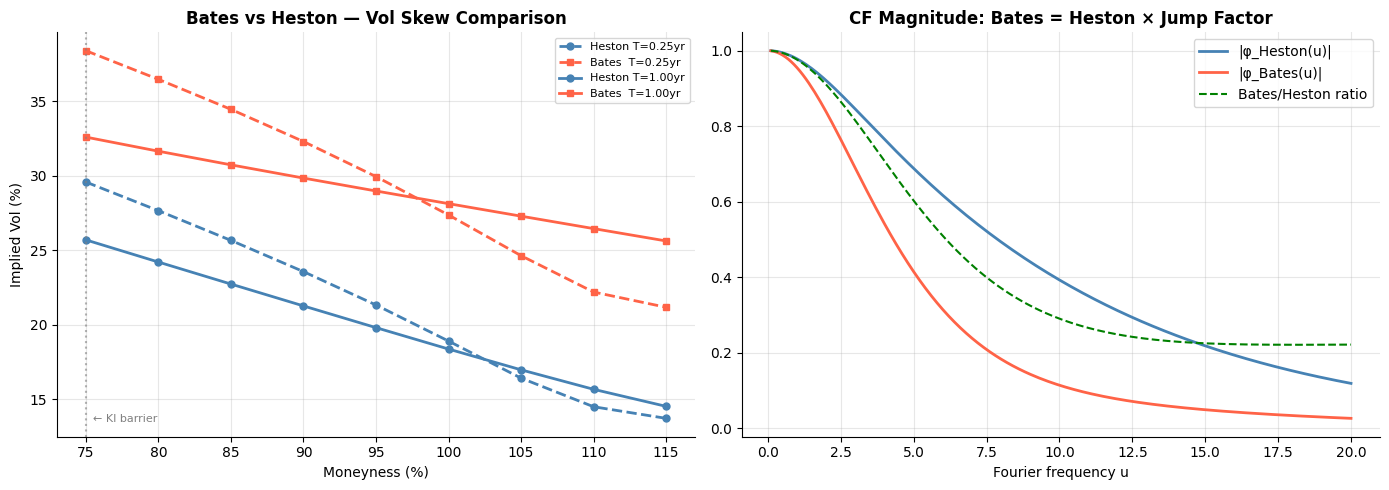

Bates CF = Heston CF × one extra exponential — all Heston pricing machinery carries over.


In [9]:
def bates_cf(u, S0, v0, kappa, theta, gamma, rho, r, q, T, lam, mu_j, sigma_j):
    '''Bates CF = Heston CF x jump component. Factorization holds by independence.'''
    phi_h  = heston_cf(u, S0, v0, kappa, theta, gamma, rho, r, q, T)
    mu_bar = np.exp(mu_j + 0.5*sigma_j**2) - 1
    jump   = np.exp(T*lam*(np.exp(1j*u*mu_j - 0.5*u**2*sigma_j**2) - 1 - 1j*u*mu_bar))
    return phi_h * jump

def bates_call(S0, K, T, r, q, v0, kappa, theta, gamma, rho, lam, mu_j, sigma_j,
               u_max=100, n_pts=200):
    log_K = np.log(K)
    def ig(u, j):
        sh  = -1j if j==1 else 0j
        ph  = bates_cf(u+sh, S0, v0, kappa, theta, gamma, rho, r, q, T, lam, mu_j, sigma_j)
        ph0 = bates_cf(sh,   S0, v0, kappa, theta, gamma, rho, r, q, T, lam, mu_j, sigma_j)
        return np.real(np.exp(-1j*u*log_K)*ph/(1j*u*ph0))
    P1 = 0.5 + integrate.quad(ig,1e-6,u_max,args=(1,),limit=n_pts)[0]/np.pi
    P2 = 0.5 + integrate.quad(ig,1e-6,u_max,args=(2,),limit=n_pts)[0]/np.pi
    return S0*np.exp(-q*T)*P1 - K*np.exp(-r*T)*P2

S0, r, q = 100, 0.05, 0.015
v0, kappa, theta, gamma, rho = 0.04, 2.0, 0.04, 0.6, -0.75
lam, mu_j, sigma_j = 1.5, -0.10, 0.15
strikes = np.array([75,80,85,90,95,100,105,110,115])

fig, axes = plt.subplots(1, 2, figsize=(14,5))

for T_demo, ls in [(0.25,'--'),(1.0,'-')]:
    h_iv = [implied_vol(heston_call(S0,K,T_demo,r,q,v0,kappa,theta,gamma,rho),S0,K,T_demo,r,q)
            for K in strikes]
    b_iv = [implied_vol(bates_call(S0,K,T_demo,r,q,v0,kappa,theta,gamma,rho,lam,mu_j,sigma_j),
                        S0,K,T_demo,r,q)
            for K in strikes]
    lbl = f'T={T_demo:.2f}yr'
    axes[0].plot(strikes/S0*100,[iv*100 for iv in h_iv],'steelblue',ls=ls,lw=2,ms=5,marker='o',label=f'Heston {lbl}')
    axes[0].plot(strikes/S0*100,[iv*100 for iv in b_iv],'tomato',   ls=ls,lw=2,ms=5,marker='s',label=f'Bates  {lbl}')

axes[0].axvline(75, color='gray', ls=':', alpha=0.6)
axes[0].text(75.5, axes[0].get_ylim()[0]+1, '← KI barrier', fontsize=8, color='gray')
axes[0].set_title('Bates vs Heston — Vol Skew Comparison', fontweight='bold')
axes[0].set_xlabel('Moneyness (%)'); axes[0].set_ylabel('Implied Vol (%)'); axes[0].legend(fontsize=8)

# Show jump component magnitude across u
u_vals = np.linspace(0.1, 20, 200)
phi_h  = np.array([heston_cf(u, S0, v0, kappa, theta, gamma, rho, r, q, 1.0) for u in u_vals])
phi_b  = np.array([bates_cf( u, S0, v0, kappa, theta, gamma, rho, r, q, 1.0, lam, mu_j, sigma_j)
                   for u in u_vals])
axes[1].plot(u_vals, np.abs(phi_h), 'steelblue', lw=2, label='|φ_Heston(u)|')
axes[1].plot(u_vals, np.abs(phi_b), 'tomato',    lw=2, label='|φ_Bates(u)|')
axes[1].plot(u_vals, np.abs(phi_b)/np.abs(phi_h), 'green', lw=1.5, ls='--', label='Bates/Heston ratio')
axes[1].set_title('CF Magnitude: Bates = Heston × Jump Factor', fontweight='bold')
axes[1].set_xlabel('Fourier frequency u'); axes[1].legend()

plt.tight_layout(); plt.show()
print("Bates CF = Heston CF × one extra exponential — all Heston pricing machinery carries over.")

---
<a id="8"></a>
## 8. Design Decisions — ADI vs CF; Gil-Pelaez vs Carr-Madan

### Why We Didn't Use ADI for Heston

#### What ADI Is

ADI (Alternating Direction Implicit) solves 2D spatial PDEs by alternating between the two spatial directions — each step reduces to a 1D tridiagonal problem. For Heston's (S, v) grid, Douglas ADI would solve in the S direction then the v direction alternately.

#### The Problem: Mixed Derivative

The Heston PDE contains: **ρ · γ · v · S · ∂²V/∂S∂v**

This term couples S and v through *diagonal* grid neighbours (V[i+1,j+1], V[i−1,j−1], V[i+1,j−1], V[i−1,j+1]). Standard Douglas ADI assumes separable dimensions — the mixed term violates this. You need Craig-Sneyd or Hundsdorfer-Verwer schemes, which are significantly more complex.

#### We Don't Need It

| Use case | Characteristic function | 2D FDM + ADI |
|---|---|---|
| European calibration (50–100 options) | ~1ms each, direct | Full grid + interpolation |
| Autocallable pricing | MC naturally handles path dependency | 2D grid + barrier BCs — complex |
| Demo explainability | Math is visible | Implementation obscures insight |

For calibration, the CF prices each option independently in 1ms. For autocallables, MC handles path dependency naturally. ADI would add ~300 lines of complexity with no demo benefit.

### Why Gil-Pelaez Not Carr-Madan

#### The Problem Carr-Madan Solves

Call price C(K) → S₀ as K → 0. A function that doesn't decay at the boundaries has no well-defined Fourier transform. **Carr-Madan (1999)** introduces a dampening factor e^{αk} (k = log K, α > 0) to force decay:

$$\tilde{c}(k) = e^{\alpha k} \cdot C(e^k) \quad \text{with closed-form Fourier transform}$$

This enables **FFT pricing** — N strikes simultaneously in O(N log N).

#### What Gil-Pelaez Does Instead

Works directly with the two risk-neutral probabilities P₁, P₂ whose integrands decay naturally. Two scalar integrals per option. No dampening parameter needed.

#### Comparison

| | Gil-Pelaez | Carr-Madan |
|---|---|---|
| Extra parameter | None | α (must satisfy κθ > ½γ²·α(α+1)) |
| Integration target | 2 scalar integrals per option | FFT over log-strike grid |
| Best for | Sparse calibration (50 options) | Dense strip repricing |
| Convergence risk | Stable for all real u | Can fail if α too large |
| Paper reference | Haugh (2013) — used here | Industry production systems |

**Decision:** Gil-Pelaez is simpler, robust, sufficient for calibration with ~50–100 observed options. Carr-Madan would be the right choice in a production system pricing a full options book in real-time.

In [ ]:
# ── ADI: Mixed Derivative Couples Diagonal Neighbours ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def plot_stencil(ax, title, points, colors, note=''):
    for (x,y), col in zip(points, colors):
        ax.scatter(x, y, s=500, c=col, zorder=3, edgecolors='white', lw=2)
    # Arrows for axis connections
    for p in [(-1,0),(1,0)]:
        ax.annotate('', xy=(0,0), xytext=p,
                    arrowprops=dict(arrowstyle='<->', color='orange', lw=2.5))
    ax.set_xlim(-1.8,1.8); ax.set_ylim(-1.8,1.8)
    ax.axhline(0,color='lightgray',lw=0.5); ax.axvline(0,color='lightgray',lw=0.5)
    ax.set_xlabel('S direction  →', fontsize=11); ax.set_ylabel('v direction  ↑', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=11); ax.set_aspect('equal')
    if note: ax.text(0, -1.65, note, ha='center', fontsize=9,
                     bbox=dict(facecolor='lightyellow',boxstyle='round',alpha=0.8))

# BS: 1D stencil (S direction only)
plot_stencil(axes[0],
    'Black-Scholes PDE Stencil -- 1D in S: simple tridiagonal',
    [(0,0),(-1,0),(1,0)],
    ['steelblue','orange','orange'],
    note='3-point S-only stencil -> simple tridiagonal -> Douglas ADI works fine')

# Heston: 2D stencil with mixed-derivative diagonals
for (x,y), col in zip(
    [(0,0),(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(1,1),(-1,1),(1,-1)],
    ['steelblue','orange','orange','green','green','tomato','tomato','tomato','tomato']):
    axes[1].scatter(x, y, s=500, c=col, zorder=3, edgecolors='white', lw=2)
for p in [(-1,0),(1,0)]:
    axes[1].annotate('',xy=(0,0),xytext=p,arrowprops=dict(arrowstyle='<->',color='orange',lw=2))
for p in [(0,-1),(0,1)]:
    axes[1].annotate('',xy=(0,0),xytext=p,arrowprops=dict(arrowstyle='<->',color='green',lw=2))
for p in [(-1,-1),(1,1),(-1,1),(1,-1)]:
    axes[1].annotate('',xy=(0,0),xytext=p,arrowprops=dict(arrowstyle='<->',color='tomato',lw=1.5,ls='dashed'))
axes[1].set_xlim(-1.8,1.8); axes[1].set_ylim(-1.8,1.8)
axes[1].axhline(0,color='lightgray',lw=0.5); axes[1].axvline(0,color='lightgray',lw=0.5)
axes[1].set_xlabel('S direction  →',fontsize=11); axes[1].set_ylabel('v direction  ↑',fontsize=11)
axes[1].set_title('Heston PDE Stencil -- 2D with mixed d2V/dSdv (diagonal coupling)',
                  fontweight='bold',fontsize=11); axes[1].set_aspect('equal')
axes[1].text(0,-1.65,'Diagonal neighbours (red): rho*gamma*v*S*d2V/dSdv\ncouples S and v => breaks Douglas ADI\nneed Craig-Sneyd or Characteristic Function',
             ha='center',fontsize=9,bbox=dict(facecolor='lightyellow',boxstyle='round',alpha=0.8))
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='steelblue',label='Centre V[i,j]'),
                         Patch(color='orange',label='S-direction'),
                         Patch(color='green',label='v-direction'),
                         Patch(color='tomato',label='Diagonal (mixed ∂²V/∂S∂v)')],
               loc='upper right',fontsize=8)
plt.tight_layout(); plt.show()

print("BS PDE:     3-point S-only stencil → single 1D tridiagonal system")
print("Heston PDE: 5-axis + 4 diagonal neighbours → S and v coupled")
print("Solution:   Craig-Sneyd ADI (complex) OR Characteristic Function (simple + faster for calibration)")

---
## Summary — The Model and Method Hierarchy

### Vol Models

| Model | State variables | Key innovation | Limitation |
|---|---|---|---|
| **Black-Scholes** | S | Closed-form, constant σ | Flat surface — no skew |
| **Dupire Local Vol** | S | σ(S,t) — exact market fit | Jagged numerically; unrealistic paths |
| **Heston** | S, v | Stochastic vol, char. function | Short-dated OTM underpriced |
| **Bates** | S, v, jumps | + Crash gap risk | 8 params, harder to calibrate |

### Pricing Methods

| Method | Best for | Key property |
|---|---|---|
| **Explicit FDM** | Teaching, simple cases | Stable only if λ ≤ ½ |
| **Crank-Nicolson** | Production PDE pricing | Unconditionally stable, 2nd-order |
| **Char. Fn + Gil-Pelaez** | European option calibration | ~1ms per option; no MC needed |
| **Standard Monte Carlo** | Path-dependent exotics | Converges as 1/√N |
| **One-Step Survival MC** | Path-dependent with barriers | 3–5× tighter CI; stable Greeks |

### App Page Mapping

| App Page | Methods Used |
|---|---|
| Vol Surface | Dupire local vol, Heston calibration (char. function + Gil-Pelaez) |
| Pricer | Crank-Nicolson FDM, Standard MC, One-Step Survival MC |
| FDM Visualization | Explicit FDM (small grid for visualization), CN |
| Greeks | Survival MC for stable ∂V/∂S and ∂V/∂σ |
| Scenarios | All methods, what-if analysis |

---
*AutoCallable Analytics Platform — v0.5.16*  
*Reference papers: Deng, Mallett & McCann (2011) · Haugh, Columbia IEOR (2013) · Alm, Harrach, Harrach & Keller (2013)*